# Brain Tumor Classifier with MLflow

This notebook builds a brain tumor classifier using MLflow for experiment tracking. We'll start with data loading and initial exploration.

## Overview
- **Data**: Brain MRI images classified as 'no' (no tumor) or 'yes' (tumor present).
- **Goal**: Train a model to classify images.
- **Tools**: PyTorch, MLflow, scikit-learn, etc.

## Imports

Import necessary libraries for data handling, visualization, and MLflow setup.

In [7]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
from torchvision import transforms
import mlflow
import mlflow.pytorch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Data Loading

Load the brain MRI images from the data directory. The data is organized into 'no' and 'yes' folders.

Class 'no': 98 images
Class 'yes': 155 images
Total images: 253


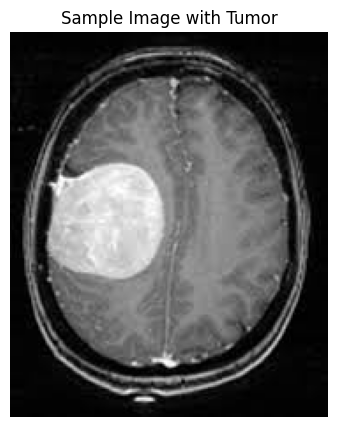

In [16]:
# Define data directory
data_dir = 'data'
classes = ['no', 'yes']

# Check number of images per class
for cls in classes:
    path = os.path.join(data_dir, cls)
    if os.path.exists(path):
        images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"Class '{cls}': {len(images)} images")
    else:
        print(f"Directory {path} does not exist")

# Collect all image paths and labels
image_paths = []
labels = []
for cls in classes:
    path = os.path.join(data_dir, cls)
    for img in os.listdir(path):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(path, img))
            labels.append(0 if cls == 'no' else 1)

print(f"Total images: {len(image_paths)}")

# Load and display a sample image
sample_path = os.path.join(data_dir, 'yes', 'Y1.jpg')
if os.path.exists(sample_path):
    sample_img = Image.open(sample_path)
    plt.figure(figsize=(5,5))
    plt.imshow(sample_img)
    plt.title("Sample Image with Tumor")
    plt.axis('off')
    plt.show()
else:
    print("Sample image not found")

## Initial Exploration

Explore the dataset: class distribution, image sizes, etc.

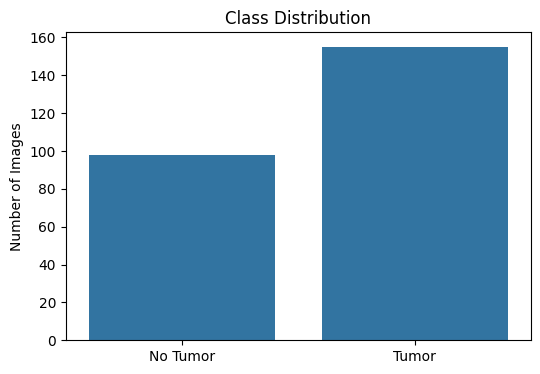

Sample image sizes: [(208, 242), (207, 243), (225, 225), (177, 197), (750, 750), (228, 221), (1920, 1080), (630, 630), (642, 361), (512, 512), (225, 225), (259, 194), (194, 259), (225, 225), (630, 630), (225, 225), (409, 442), (728, 725), (630, 630), (428, 417)]
Unique sizes: {(177, 197), (207, 243), (1920, 1080), (512, 512), (225, 225), (630, 630), (642, 361), (409, 442), (428, 417), (728, 725), (228, 221), (194, 259), (750, 750), (208, 242), (259, 194)}
DataFrame head:
                path  label
0  data/no/30 no.jpg      0
1  data/no/22 no.jpg      0
2  data/no/41 no.jpg      0
3  data/no/14 no.jpg      0
4  data/no/no 10.jpg      0


In [9]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title('Class Distribution')
plt.xticks([0,1], ['No Tumor', 'Tumor'])
plt.ylabel('Number of Images')
plt.show()

# Check image sizes (sample of 20 images)
sizes = []
for path in image_paths[:20]:
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except Exception as e:
        print(f"Error loading {path}: {e}")

print("Sample image sizes:", sizes)
unique_sizes = set(sizes)
print("Unique sizes:", unique_sizes)

# Create a DataFrame for easier handling
df = pd.DataFrame({'path': image_paths, 'label': labels})
print("DataFrame head:")
print(df.head())

## MLflow Setup

Set up MLflow for experiment tracking.

In [10]:
# Set up MLflow experiment
mlflow.set_experiment("Brain Tumor Classifier")
print("MLflow experiment set to 'Brain Tumor Classifier'")

MLflow experiment set to 'Brain Tumor Classifier'


## Data Preprocessing and Splitting

Resize images to a common size and split the dataset into train, validation, and test sets.

In [17]:
from torch.utils.data import Dataset, DataLoader

# Define a custom dataset class
class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split the dataset
# First, split into train+val and test (80% train+val, 20% test)
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Then, split train+val into train and val (75% train, 25% val of the 80%, so 60% and 20% overall)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.25, random_state=42, stratify=train_val_labels
)

# Create datasets
train_dataset = BrainTumorDataset(train_paths, train_labels, transform=train_transform)
val_dataset = BrainTumorDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = BrainTumorDataset(test_paths, test_labels, transform=val_test_transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

Train set: 151 images
Validation set: 51 images
Test set: 51 images


## Model Building

Define a convolutional neural network for binary classification. We'll use a pre-trained ResNet18 model and fine-tune it for our brain tumor classification task.

In [24]:
# Load pre-trained EfficientNetV2-S model
model = torchvision.models.efficientnet_v2_s(weights=torchvision.models.EfficientNet_V2_S_Weights.DEFAULT)

# Modify the final layer for binary classification (2 classes: no tumor, tumor)
num_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_features, 2)

# Move model to device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded and modified. Using device: {device}")
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /Users/williamdieterfrank/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100.0%


Model loaded and modified. Using device: cpu
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0

## Training

Train the model using the training set, validate on the validation set, and log metrics with MLflow.

In [25]:
# Define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training parameters
num_epochs = 10

# Start MLflow run
with mlflow.start_run():
    mlflow.log_param("model", "EfficientNetV2-S")
    mlflow.log_param("epochs", num_epochs)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("learning_rate", 0.0001)
    mlflow.log_param("data_augmentation", "RandomHorizontalFlip, RandomRotation(10), ColorJitter(brightness=0.2, contrast=0.2)")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Log to MLflow
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_accuracy", train_acc, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_acc, step=epoch)

    # Save model
    mlflow.pytorch.log_model(model, "model")
    print("Model trained and logged to MLflow.")

Epoch 1/10, Train Loss: 0.6938, Train Acc: 52.32%, Val Loss: 0.7311, Val Acc: 45.10%
Epoch 2/10, Train Loss: 0.5366, Train Acc: 80.13%, Val Loss: 0.7232, Val Acc: 45.10%
Epoch 3/10, Train Loss: 0.4381, Train Acc: 87.42%, Val Loss: 0.5951, Val Acc: 66.67%
Epoch 4/10, Train Loss: 0.2976, Train Acc: 93.38%, Val Loss: 0.3719, Val Acc: 86.27%
Epoch 5/10, Train Loss: 0.2345, Train Acc: 94.70%, Val Loss: 0.3125, Val Acc: 88.24%
Epoch 6/10, Train Loss: 0.1355, Train Acc: 97.35%, Val Loss: 0.2768, Val Acc: 90.20%
Epoch 7/10, Train Loss: 0.0958, Train Acc: 98.01%, Val Loss: 0.2372, Val Acc: 94.12%
Epoch 8/10, Train Loss: 0.0609, Train Acc: 98.68%, Val Loss: 0.2157, Val Acc: 96.08%
Epoch 9/10, Train Loss: 0.0359, Train Acc: 100.00%, Val Loss: 0.2198, Val Acc: 92.16%


2025/09/28 23:08:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 10/10, Train Loss: 0.0446, Train Acc: 99.34%, Val Loss: 0.2005, Val Acc: 92.16%


2025/09/28 23:08:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/09/28 23:08:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model trained and logged to MLflow.


## Evaluation

Evaluate the trained model on the test set and generate a classification report.

Test Accuracy: 88.24%
Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.85      0.85      0.85        20
       Tumor       0.90      0.90      0.90        31

    accuracy                           0.88        51
   macro avg       0.88      0.88      0.88        51
weighted avg       0.88      0.88      0.88        51



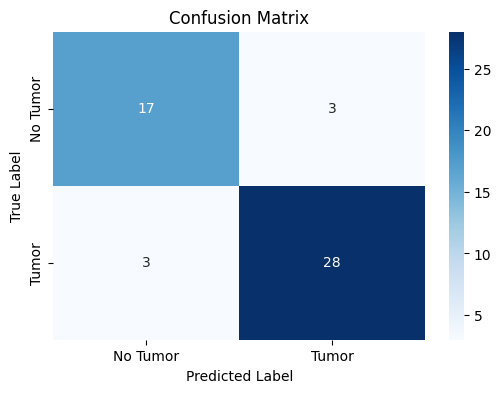

Test metrics logged to MLflow.


In [26]:
# Evaluate on test set
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
report = classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor'])
print("Classification Report:")
print(report)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Log test metrics to MLflow (assuming still in run context, or start new)
with mlflow.start_run():
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_text(report, "classification_report.txt")
    print("Test metrics logged to MLflow.")